In [1]:
# load a trained model
from pathlib import Path

import torch as tc

from models import ConvNet

device = tc.device("cuda")

SHAPE = (1, 100, 100)
model = ConvNet(shape=SHAPE).to(device)

# model_state_path = Path("./weights", f"{model.name}.pt")
model_state_path = Path("./weights", f"{model.name}_fold0_best.pt")
model.load_state_dict(tc.load(model_state_path, weights_only=True))
model.eval()

ConvNet(
  (conv0): Conv2d(1, 64, kernel_size=(7, 7), stride=(2, 2), padding=(4, 4))
  (conv1): Conv2d(64, 128, kernel_size=(5, 5), stride=(2, 2), padding=(2, 2))
  (conv2): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (features): Sequential(
    (0): Conv2d(1, 64, kernel_size=(7, 7), stride=(2, 2), padding=(4, 4))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=(2, 2), stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Dropout2d(p=0.25, inplace=False)
    (5): Conv2d(64, 128, kernel_size=(5, 5), stride=(2, 2), padding=(2, 2))
    (6): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (7): ReLU()
    (8): MaxPool2d(kernel_size=(2, 2), stride=2, padding=0, dilation=1, ceil_mode=False)
    (9): Dropout2d(p=0.25, inplace=False)
    (10): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11):

In [2]:
from torch.utils.data import DataLoader
from torchvision.datasets import ImageFolder
import torchvision.transforms.v2 as tvs

import numpy as np

transforms = tvs.Compose([
    tvs.Grayscale(),
    tvs.ToTensor(),
    tvs.Resize(100),
    tvs.CenterCrop(100),
    tvs.Normalize(mean=(0.5,), std=(0.5,)), # TODO: compute statistics from dataset instead
])

ROOT = Path("data/MalariaDataset/train")
dataset = ImageFolder("data/cats_and_dogs/PetImages", transform=transforms)

SAMPLES = [0, 500, 1000, 5000, 5001, 5002]
target_sample_loader = DataLoader(dataset, sampler=SAMPLES, batch_size=10)
images, labels = next(iter(target_sample_loader))
images, labels = images.to(device), labels.to(device)

c:\Users\User\Desktop\ADR\Repository\xai-binary-classification\.venv\Lib\site-packages\torchvision\transforms\v2\_deprecated.py:42: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.Output is equivalent up to float precision.
  warnings.warn(


In [3]:
from captum.attr import (
    Lime,
    Saliency,
    InputXGradient,
    GuidedBackprop,
    GuidedGradCam,
    Deconvolution,
    NoiseTunnel,
    Occlusion,
)

# keep it deterministic
tc.manual_seed(0)
np.random.seed(0)

attribution_methods = {
    "lime": Lime(model).attribute(
        images,
        target=None,
        n_samples=5000,
        perturbations_per_eval=200,
        show_progress=True,
    ),
    "saliency": Saliency(model).attribute(images, target=None, abs=False),
    "input x gradient": InputXGradient(model).attribute(images, target=None),
    "guided backprop": GuidedBackprop(model).attribute(images, target=None),
    "guided gradcam": GuidedGradCam(model, layer=model.conv0).attribute(
        images, target=None
    ),
    "deconvolution": Deconvolution(model).attribute(images, target=None),
    "smoothed guided backprop": NoiseTunnel(GuidedBackprop(model)).attribute(
        images, target=None
    ),
    "occlusion": Occlusion(model).attribute(images, sliding_window_shapes=(1, 10, 10), strides=2, target=None),
}

c:\Users\User\Desktop\ADR\Repository\xai-binary-classification\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\Users\User\Desktop\ADR\Repository\xai-binary-classification\.venv\Lib\site-packages\captum\attr\_core\lime.py:1169: UserWarning: You are providing multiple inputs for Lime / Kernel SHAP attributions. This trains a separate interpretable model for each example, which can be time consuming. It is recommended to compute attributions for one example at a time.
  warnings.warn(
Lime attribution: 100%|██████████| 25/25 [00:02<00:00, 11.81it/s]
c:\Users\User\Desktop\ADR\Repository\xai-binary-classification\.venv\Lib\site-packages\captum\attr\_core\saliency.py:129: UserWarning: Input Tensor 0 did not already require gradients, required_grads has been set automatically.
  gradient_mask = apply_gradient_re

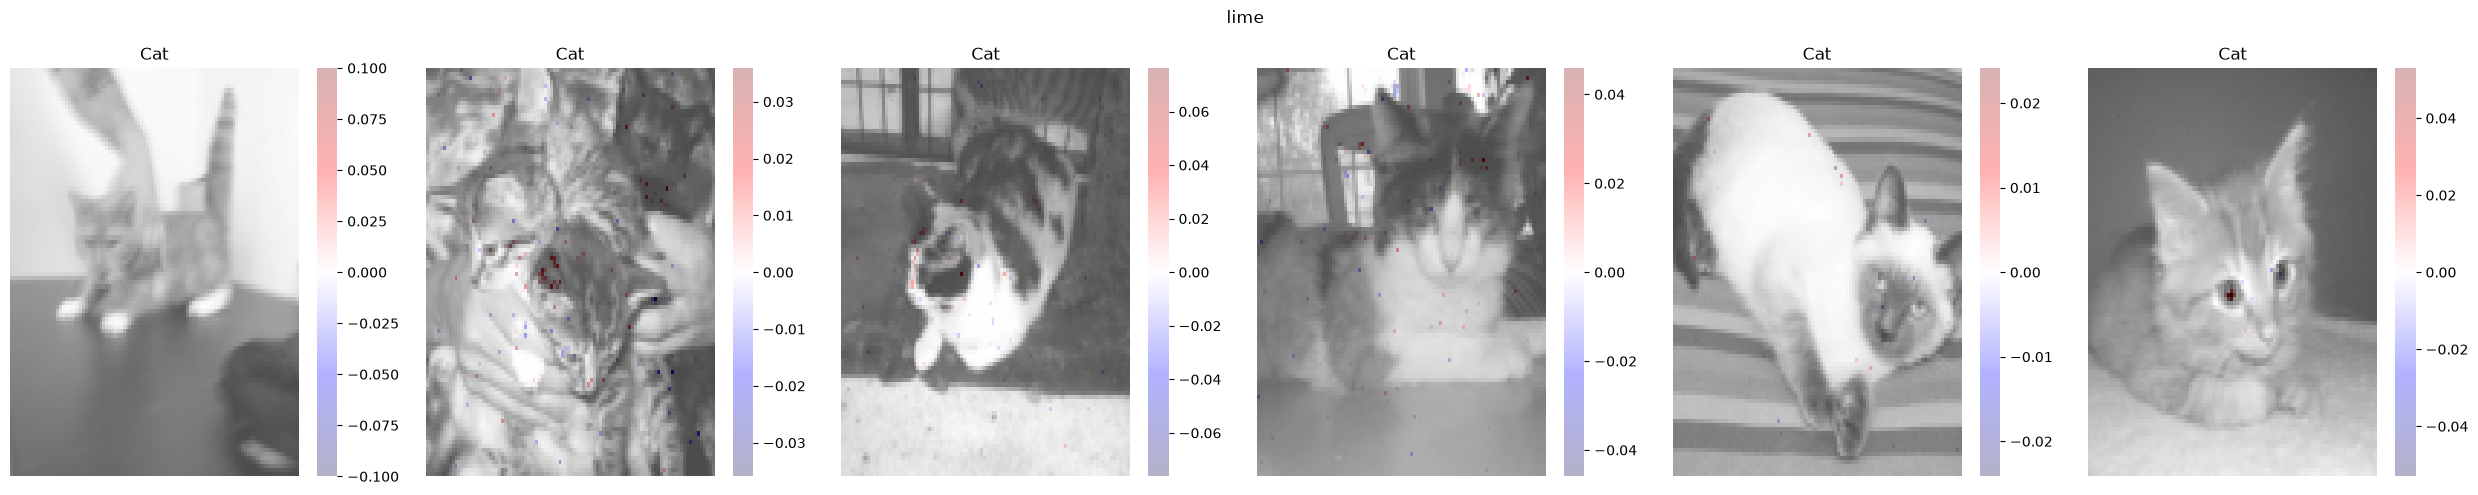

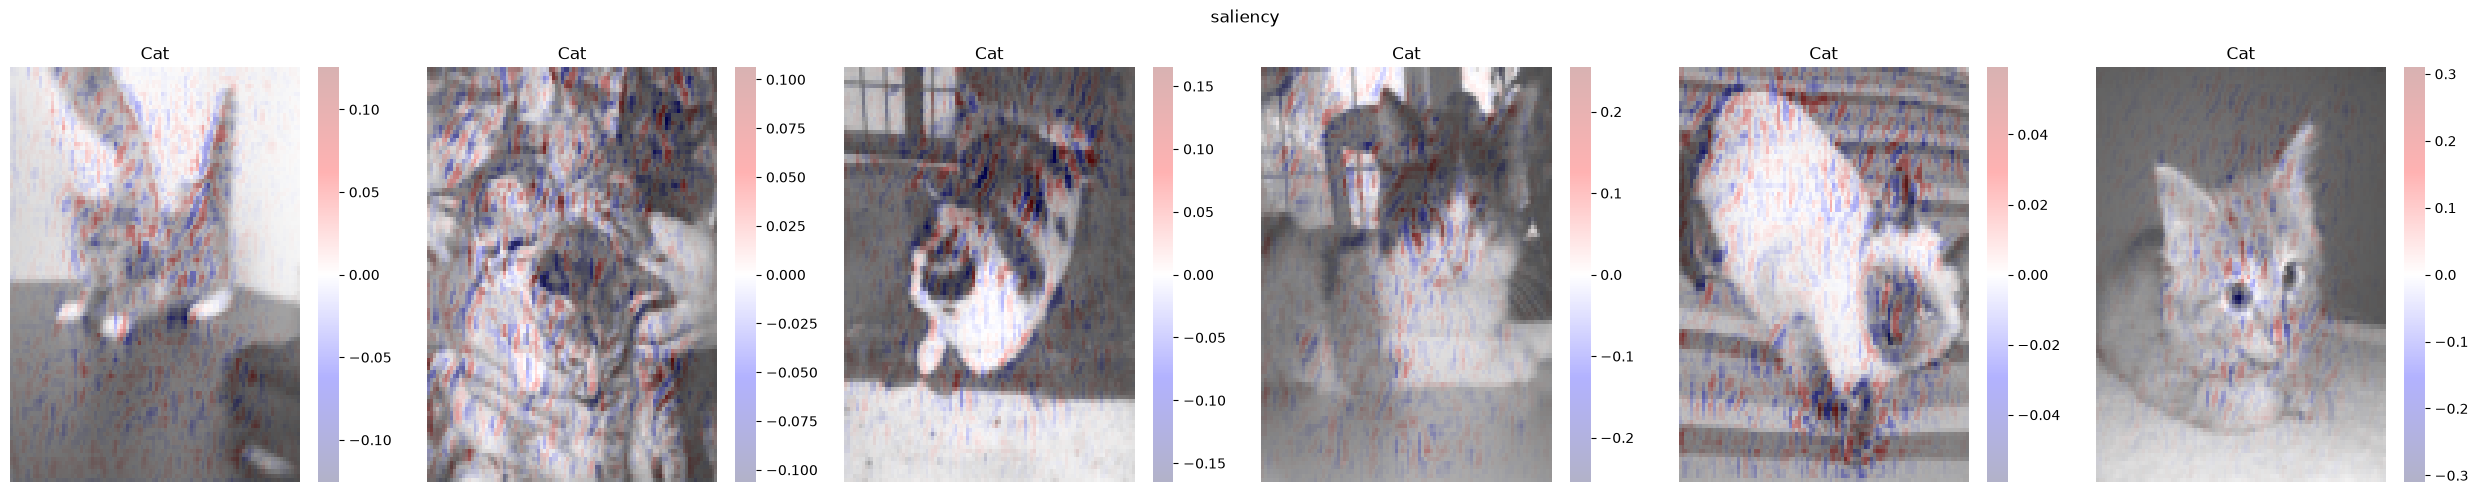

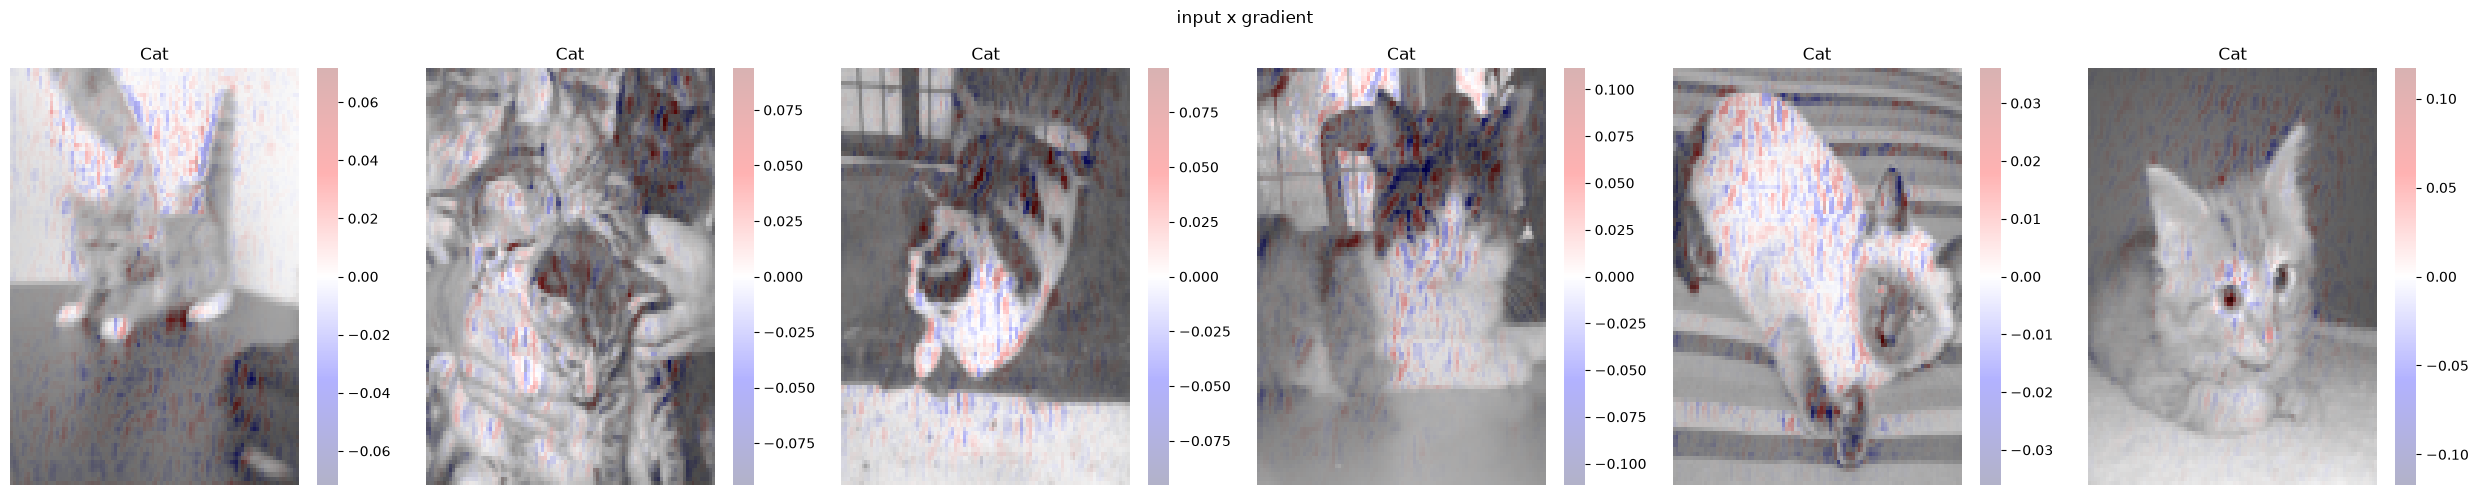

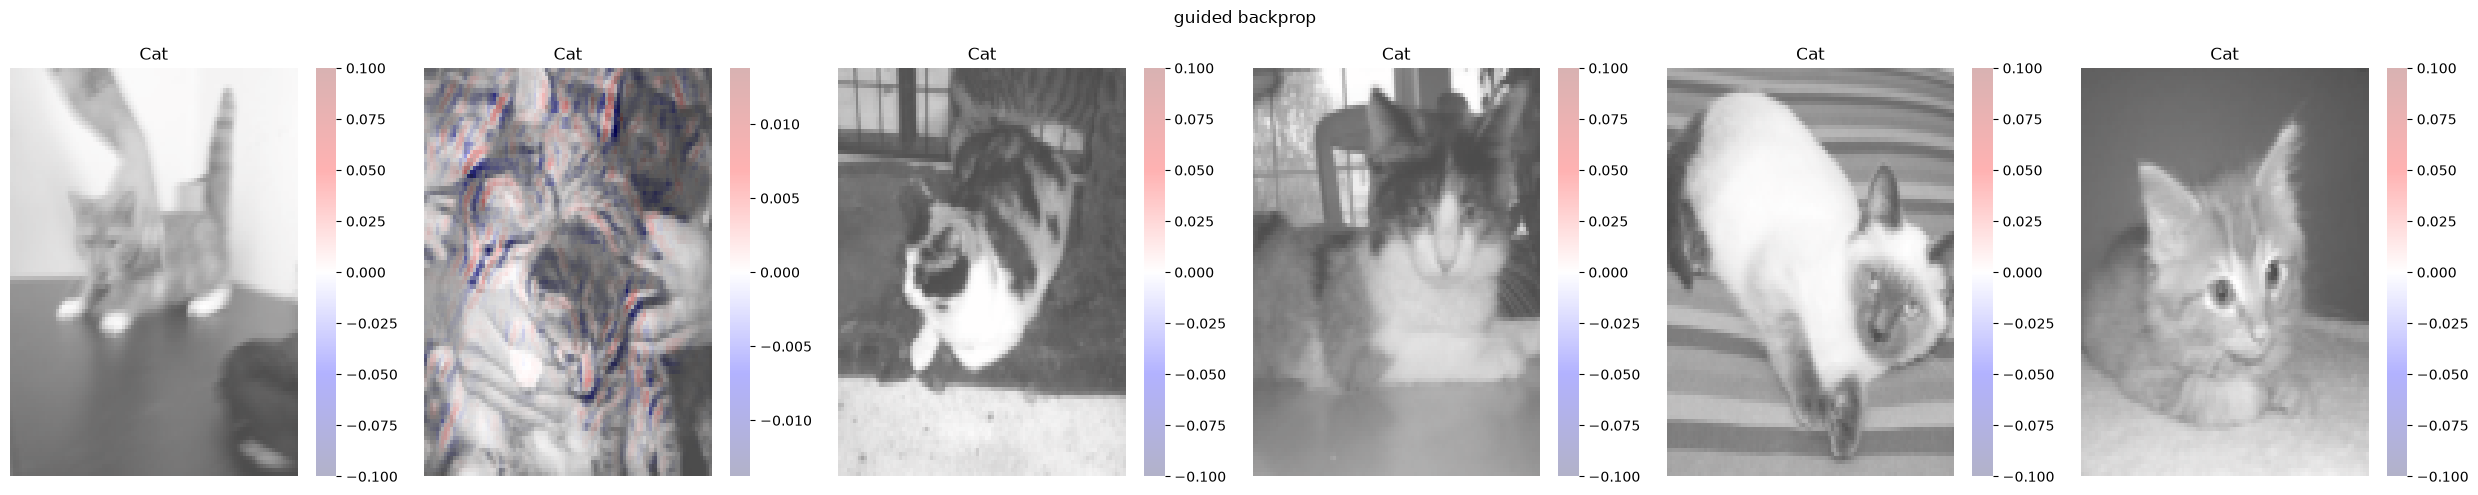

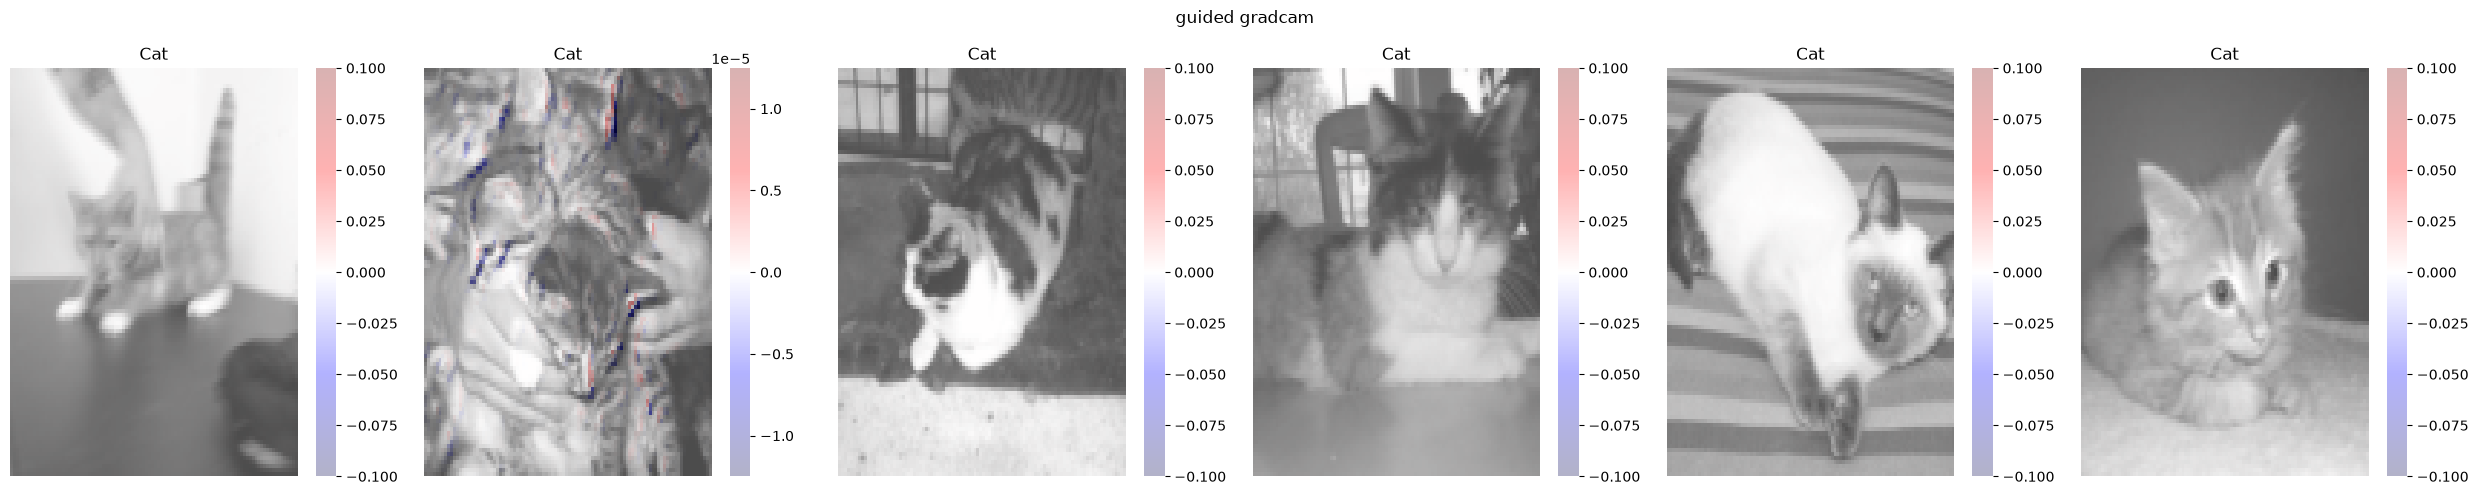

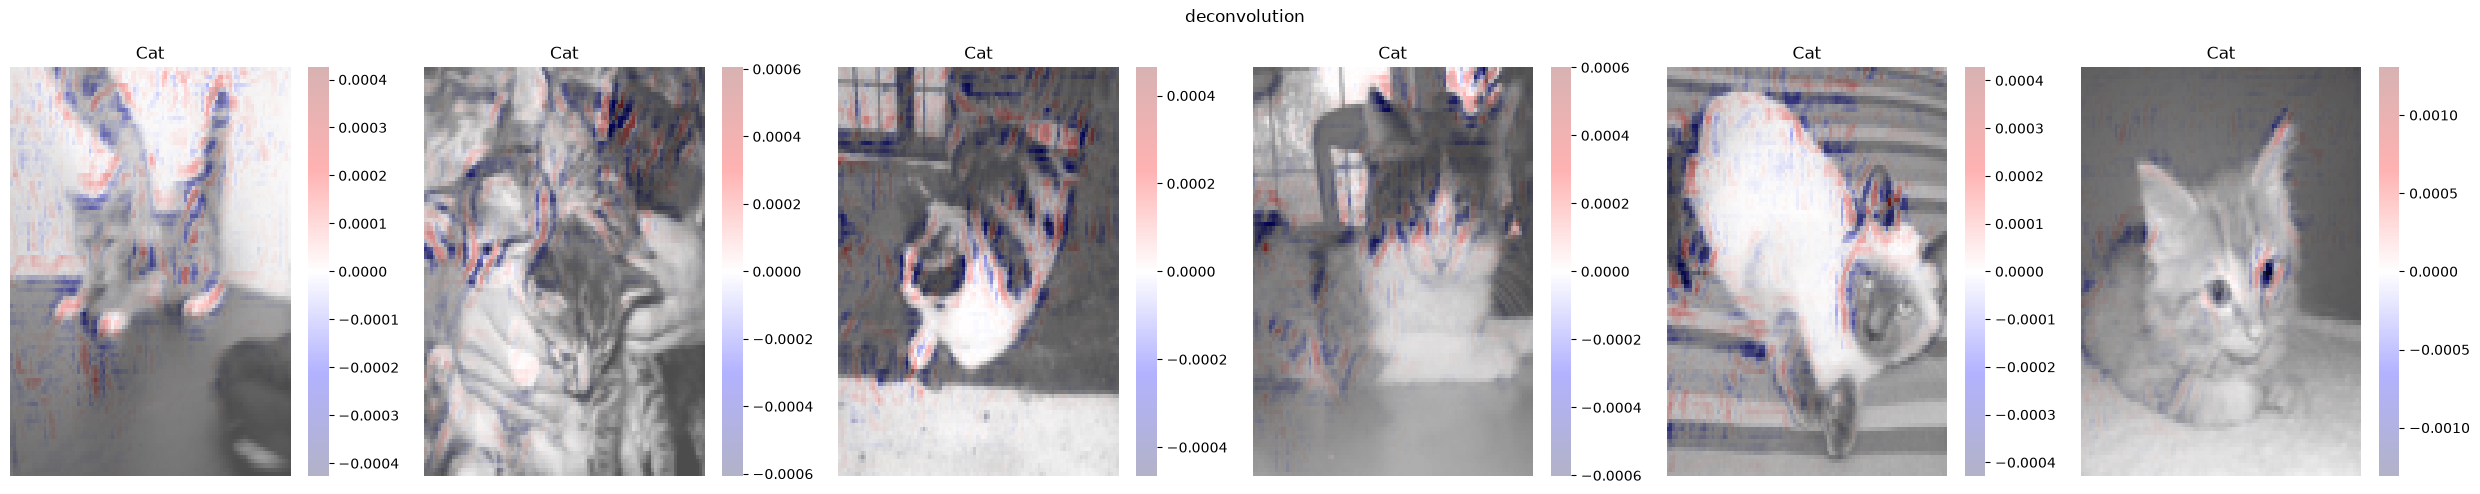

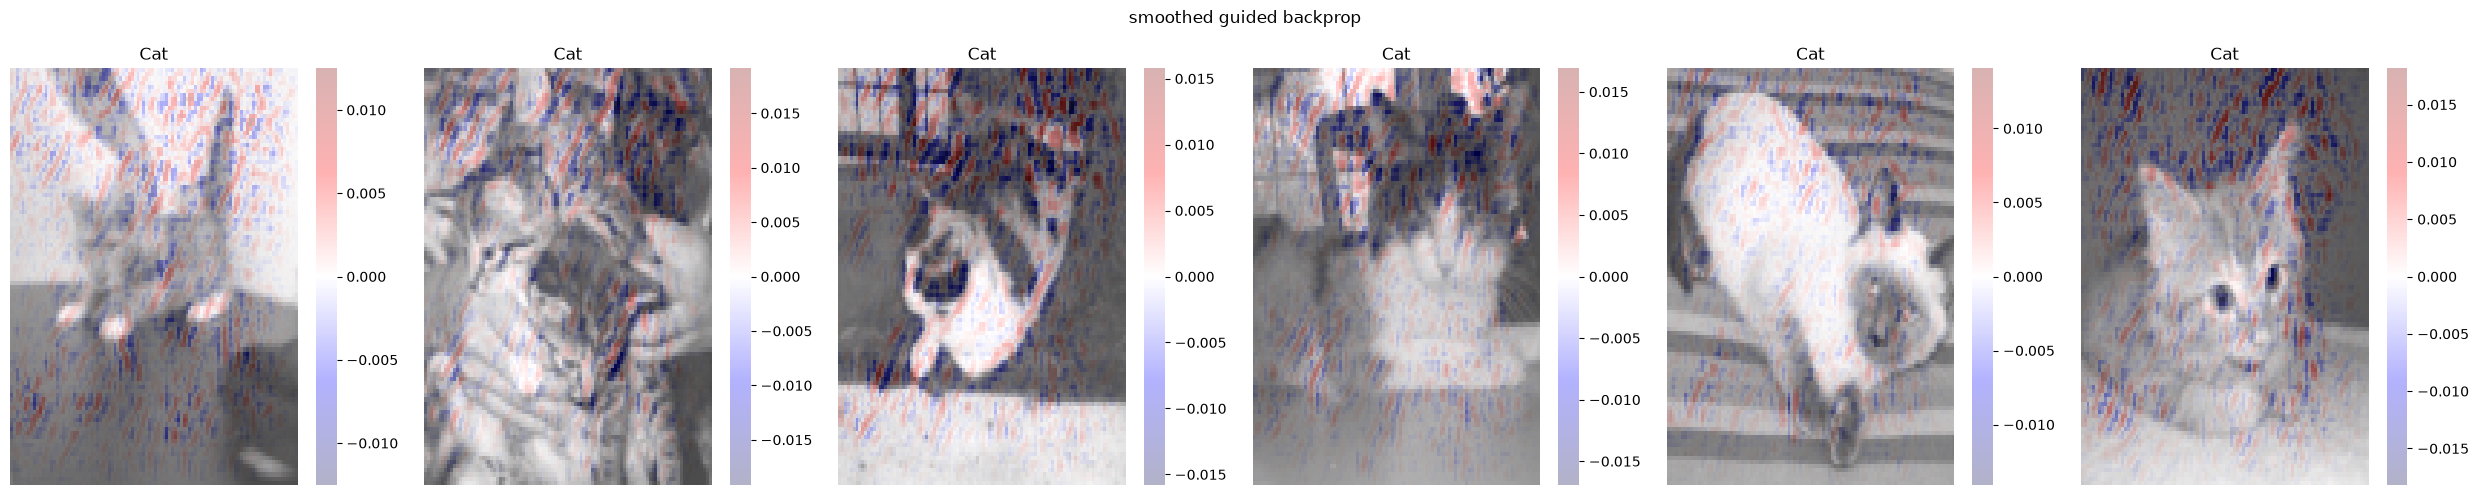

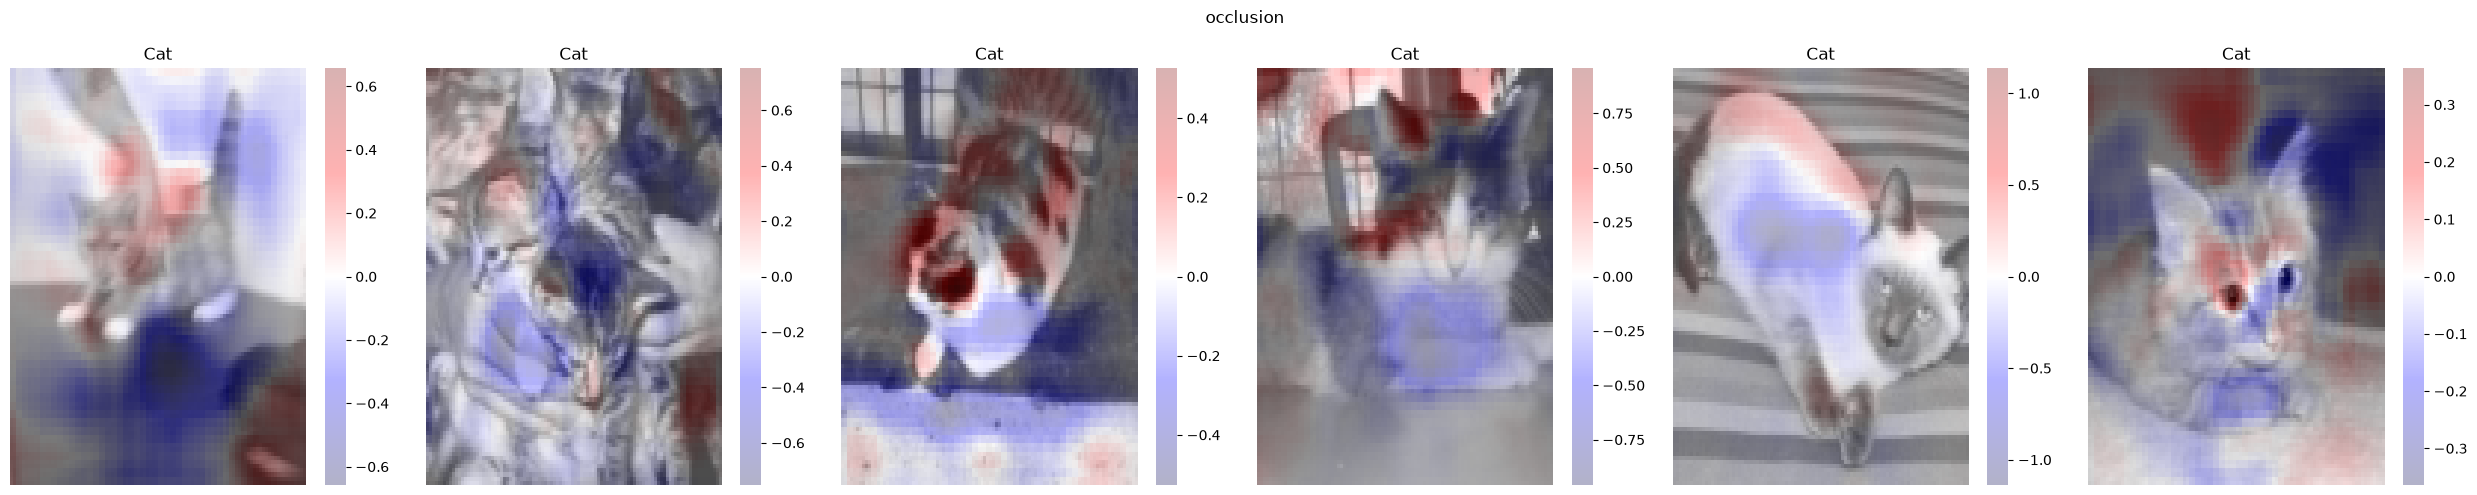

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

for method, attributions in attribution_methods.items():
    # convert for visualization
    attributions = attributions.mean(dim=1).detach().cpu().numpy()

    fig, axes = plt.subplots(nrows=1, ncols=len(attributions), figsize=(25, 5))
    fig.suptitle(method)
    for i in range(len(attributions)):
        sns.heatmap(images[i].mean(dim=0).detach().cpu().numpy(), ax=axes[i], cmap='gray', alpha=1, cbar=False)
        sns.heatmap(attributions[i], ax=axes[i], cmap='seismic', alpha=0.3, vmax=np.abs(attributions[i]).max(), vmin=-np.abs(attributions[i]).max(), cbar=True)
        axes[i].set_title(dataset.classes[labels[i].item()])
        axes[i].axis('off')

    plt.tight_layout()
    plt.show()
